# Qiskit Aer playground

This notebook follows the current Qiskit Aer workflow: build a circuit, transpile it for `AerSimulator`, run shots, and inspect the results. Run the cells from top to bottom with **Shift+Enter**.

In [1]:
import sys
import qiskit
import qiskit_aer

print("Python:", sys.version.split()[0])
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)

Python: 3.14.6
Qiskit: 2.5.2
Qiskit Aer: 0.17.2


## 1. Create an entangled Bell pair

The Hadamard gate creates a superposition, and the controlled-X gate entangles the two qubits. Ideally, measurement returns only `00` or `11`.

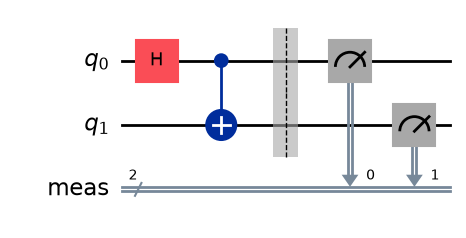

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

## 2. Simulate measurement shots

A simulator still samples probabilistic measurement outcomes. Increase `shots` to make the histogram approach a 50/50 split.

{'11': 518, '00': 506}


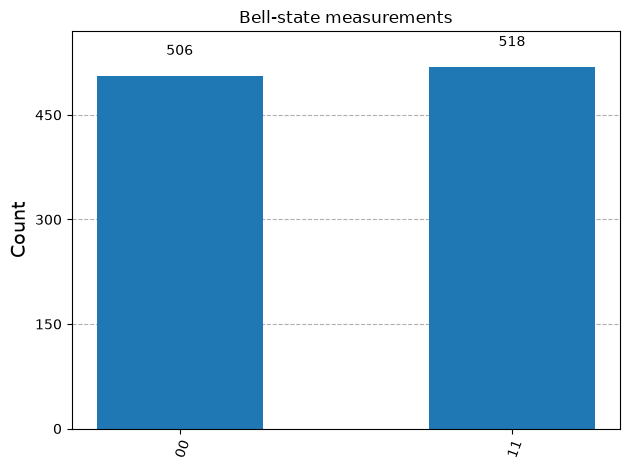

In [3]:
simulator = AerSimulator()
compiled_bell = transpile(bell, simulator)
result = simulator.run(compiled_bell, shots=1024).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts, title="Bell-state measurements")

## 3. Use Aer SamplerV2

Aer also exposes Qiskit's newer primitives interface. This is useful when algorithms expect a sampler instead of a backend.

In [4]:
from qiskit_aer.primitives import SamplerV2

sampler = SamplerV2()
sampler_result = sampler.run([bell], shots=128).result()
sampler_counts = sampler_result[0].data.meas.get_counts()
print(sampler_counts)

{'00': 65, '11': 63}


## 4. Add a simple noise model

Here each one-qubit gate has a 2% depolarizing error and each two-qubit gate has a 5% error. Noise introduces outcomes other than `00` and `11`.

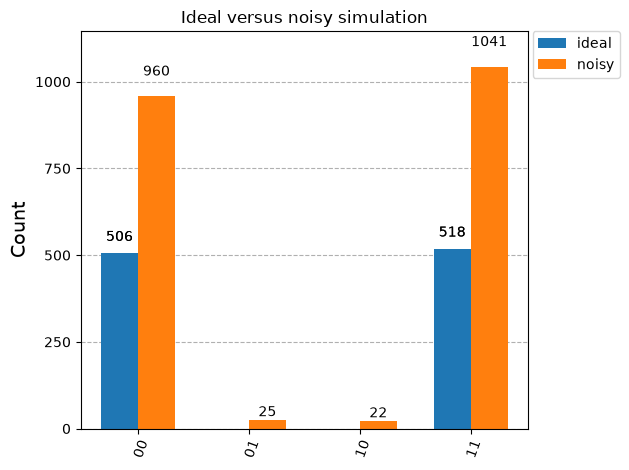

In [5]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 1), ["h"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05, 2), ["cx"])

noisy_simulator = AerSimulator(noise_model=noise_model)
noisy_bell = transpile(bell, noisy_simulator)
noisy_counts = noisy_simulator.run(noisy_bell, shots=2048).result().get_counts()
plot_histogram(
    [counts, noisy_counts],
    legend=["ideal", "noisy"],
    title="Ideal versus noisy simulation",
)

## Things to try

1. Change the number of shots and rerun the histogram.
2. Remove `bell.cx(0, 1)` and predict the outcome before running.
3. Change the noise probabilities and compare the plots.
4. Make a three-qubit GHZ circuit by adding a third qubit and another controlled-X gate.
5. Explore the official [Qiskit Aer tutorials](https://qiskit.github.io/qiskit-aer/tutorials/) and [simulation guide](https://qiskit.qotlabs.org/docs/guides/simulate-with-qiskit-aer).

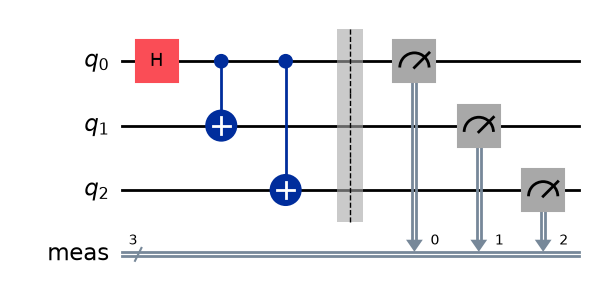

In [9]:
ghz = QuantumCircuit(3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)
ghz.measure_all()
ghz.draw("mpl")

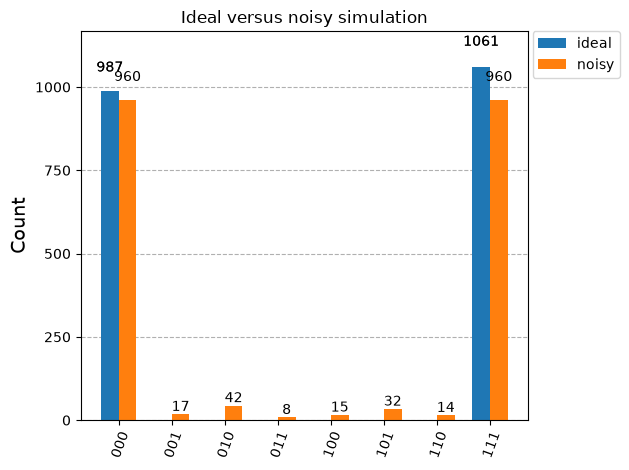

In [12]:
sim = AerSimulator()
trans_ghz = transpile(ghz, sim)
counts = sim.run(trans_ghz, shots=2048).result().get_counts()

noisy_simulator = AerSimulator(noise_model=noise_model)
noisy_ghz = transpile(ghz, noisy_simulator)
noisy_counts = noisy_simulator.run(noisy_ghz, shots=2048).result().get_counts()
plot_histogram(
    [counts, noisy_counts],
    legend=["ideal", "noisy"],
    title="Ideal versus noisy simulation",
)

In [20]:
# Tell Aer to save the quantum state
ghz.save_statevector()

qc = QuantumCircuit(3)

qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

# Tell Aer to save the quantum state
qc.save_statevector()

simulator = AerSimulator(method="statevector")

result = simulator.run(qc).result()

state = result.get_statevector()

print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


In [24]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

for method in [
    "statevector",
    "density_matrix",
    "matrix_product_state",
    "stabilizer"
]:
    simulator = AerSimulator(method=method, noise_model=noise_model)

    compiled = transpile(bell, simulator)

    result = simulator.run(
        compiled,
        shots=1000
    ).result()

    print(method, result.get_counts())

statevector {'11': 490, '00': 486, '01': 14, '10': 10}
density_matrix {'00': 501, '11': 472, '01': 17, '10': 10}
matrix_product_state {'11': 497, '00': 477, '01': 18, '10': 8}
stabilizer {'00': 484, '11': 492, '01': 10, '10': 14}


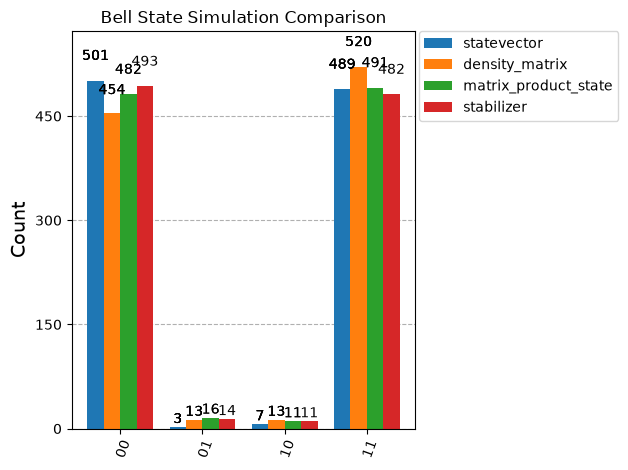

In [32]:
from qiskit.visualization import plot_histogram

all_counts = []
labels = []

for method in [
    "statevector",
    "density_matrix",
    "matrix_product_state",
    "stabilizer"
]:
    simulator = AerSimulator(
        method=method,
        noise_model=noise_model
    )

    compiled = transpile(bell, simulator)

    result = simulator.run(
        compiled,
        shots=1000
    ).result()

    all_counts.append(result.get_counts())
    labels.append(method)

plot_histogram(
    all_counts,
    legend=labels,
    title="Bell State Simulation Comparison"
)